# Efficient frontier

A single `MeanRisk` objective returns *one* portfolio. The **efficient frontier** is the
whole curve: the set of portfolios that earn the most return for each level of risk (equivalently,
that take the least risk for each level of return). Instead of committing to one risk/return point
up front, you trace the entire trade-off and choose by eye, hand it to a stakeholder, or feed the
sweep to a downstream selection rule.

This example does three things the [`MeanRisk` objectives](01_MeanRisk_Objectives.md) page does
not. First, it shows the frontier traced from **both** directions — minimising risk at a return
floor, and maximising return at a risk ceiling — and that they recover the same curve. Second, it
introduces the `Frontier` helper, which computes the sweep bounds automatically. Third, it
contrasts the extreme `MeanRisk` frontier with the **centred** frontier produced by
`NearOptimalCentering`, which trades a sliver of optimality for a more diversified, stable
allocation at every point.

> **When to reach for this**
>
> Reach for an efficient frontier when you do not want to commit to a single risk/return
> point up front — you want to *see the whole trade-off curve* and choose a portfolio by
> eye, hand it to a stakeholder, or feed the sweep to a downstream selection rule. It is
> the natural next step once you understand the `MeanRisk` objectives: instead of
> one objective value, you sweep the risk/return frontier. For more than two competing
> criteria, see the [Pareto surface](03_Pareto_Surface.md) example.

In [1]:
using PortfolioOptimisers, PrettyTables
# Format for pretty tables.
tsfmt = (v, i, j) -> begin
    if j == 1
        return Date(v)
    else
        return v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other optimiser examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
pretty_table(X[(end - 5):end]; formatters = [tsfmt])

# Compute the returns
rd = prices_to_returns(X)

┌────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬──────
│  timestamp │    AAPL │     AMD │     BAC │     BBY │     CVX │      GE │     ⋯
│       Date │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Flo ⋯
├────────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼──────
│ 2022-12-20 │ 131.916 │   65.05 │  31.729 │  77.371 │ 169.497 │  62.604 │ 310 ⋯
│ 2022-12-21 │ 135.057 │   67.68 │  32.212 │  78.729 │  171.49 │   64.67 │ 314 ⋯
│ 2022-12-22 │ 131.846 │   63.86 │  31.927 │  78.563 │ 168.918 │  63.727 │ 311 ⋯
│ 2022-12-23 │ 131.477 │   64.52 │  32.005 │  79.432 │  174.14 │  63.742 │ 314 ⋯
│ 2022-12-27 │ 129.652 │   63.27 │  32.065 │   79.93 │ 176.329 │  64.561 │ 314 ⋯
│ 2022-12-28 │ 125.674 │   62.57 │  32.301 │  78.279 │ 173.728 │  63.883 │  31 ⋯
└────────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴──────
                                                              14 columns omitted


ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. Two directions, four combinations

There are two mutually exclusive ways to trace a frontier:

  - **Minimise risk** subject to a *lower bound on return* — sweep the return floor upward.
  - **Maximise return** subject to an *upper bound on risk* — sweep the risk ceiling upward.

Each bound can be supplied **explicitly** (a `range` of numbers you pick) or as a
`Frontier` object, which inspects the problem, finds the feasible extremes, and lays out
the sweep for you. That is the four combinations — two directions × explicit/automatic bounds — and
they all have their uses. The two directions trace the *same* curve; the choice is about which
quantity is more natural to pin in your problem.

We will use the `ConditionalValueatRisk` measure throughout, and precompute the prior once
so every optimisation reuses it. Since we run many optimisations and cannot assume a single solver
configuration converges at every point, we pass a *vector* of solver settings and let the optimiser
fall back through them.

In [3]:
using Clarabel
slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.75),
              check_sol = (; allow_local = true, allow_almost = true))]

r = ConditionalValueatRisk()
pr = prior(EmpiricalPrior(), rd)
rf = 4.2 / 100 / 252

0.0001666666666666667

### Direction A — minimise risk along a return floor

We minimise CVaR (the default objective) while a `Frontier` sweeps the return lower bound,
giving a 30-point frontier. The lower bound lives on the *return* side, so it is set through
`ArithmeticReturn`'s `lb`.

In [4]:
optA = JuMPOptimiser(; pe = pr, slv = slv,
                     ret = ArithmeticReturn(; lb = Frontier(; N = 30)))
resA = optimise(MeanRisk(; opt = optA, r = r))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

`retcode` and `sol` are now *vectors* — one entry per frontier point. We had no warnings about
failed optimisations, but let's confirm every point solved.

In [5]:
all(x -> isa(x, OptimisationSuccess), resA.retcode)

true

The weights evolve smoothly from the low-risk end (diversified) toward the high-return end
(concentrated) as we walk up the frontier.

In [6]:
pretty_table(DataFrame([rd.nx hcat(resA.w...)], Symbol.([:assets; 1:30]));
             formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────
│ assets │        1 │        2 │        3 │        4 │        5 │        6 │   ⋯
│    Any │      Any │      Any │      Any │      Any │      Any │      Any │   ⋯
├────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼────
│   AAPL │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │   ⋯
│    AMD │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │   ⋯
│    BAC │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │   ⋯
│    BBY │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │   ⋯
│    CVX │ 13.167 % │ 12.757 % │  9.552 % │  3.037 % │  1.821 % │  0.159 % │   ⋯
│     GE │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │   ⋯
│     HD │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │   ⋯
│    JNJ │ 45.342 % │ 40.238 % │ 37.261 % │ 32.596 % │ 29.384 % │ 26.772 % │ 2 ⋯
│    JPM │    0.0 % │    0.0

### Direction B — maximise return under a risk ceiling

The dual route: maximise return while a `Frontier` sweeps an *upper bound on CVaR*. The
bound now lives on the *risk* side, so it is attached to the risk measure through its
`RiskMeasureSettings`. Everything else is identical.

In [7]:
optB = JuMPOptimiser(; pe = pr, slv = slv)
resB = optimise(MeanRisk(; opt = optB, obj = MaximumReturn(),
                         r = ConditionalValueatRisk(;
                                                    settings = RiskMeasureSettings(;
                                                                                   ub = Frontier(;
                                                                                                 N = 30)))))
all(x -> isa(x, OptimisationSuccess), resB.retcode)

true

The two directions trace the same trade-off curve. Computing the CVaR and the arithmetic return of
each point lets us overlay them: the risk-floor sweep and the return-ceiling sweep land on top of
one another (up to where the automatic bounds place their points).

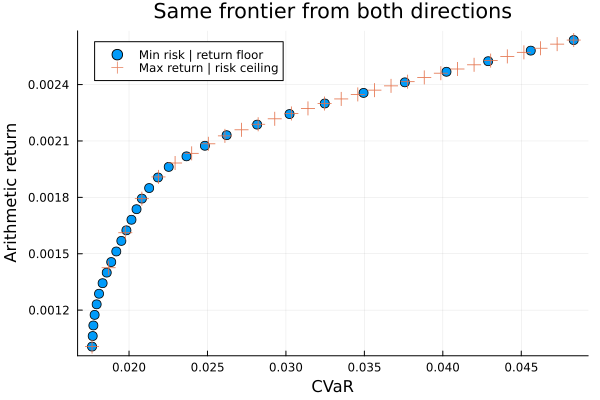

In [8]:
rcvar = factory(ConditionalValueatRisk(), pr)
xs_A = [expected_risk(rcvar, w, pr.X) for w in resA.w]
ys_A = [expected_return(ArithmeticReturn(), w, pr) for w in resA.w]
xs_B = [expected_risk(rcvar, w, pr.X) for w in resB.w]
ys_B = [expected_return(ArithmeticReturn(), w, pr) for w in resB.w]

using StatsPlots, GraphRecipes

plot(xs_A, ys_A; seriestype = :scatter, marker = (:circle, 5),
     label = "Min risk | return floor", xlabel = "CVaR", ylabel = "Arithmetic return",
     title = "Same frontier from both directions")
plot!(xs_B, ys_B; seriestype = :scatter, marker = (:cross, 7),
      label = "Max return | risk ceiling")

## 3. The `MeanRisk` frontier vs the `NearOptimalCentering` frontier

The frontier above is built from *extreme* points — each one exactly extremises the objective, and
the high-return end loads heavily on a couple of names. `NearOptimalCentering` (NOC) traces
a **centred** frontier instead: at each point it returns the portfolio at the analytic centre of
the near-optimal neighbourhood rather than the corner. The result sits just inside the extreme
frontier — slightly less optimal, noticeably more diversified and more stable to changes in the
prior. (NOC's neighbourhood-centring behaviour is dissected on its own
[page](15_Near_Optimal_Centering.md); here we only use it as a frontier engine.)

NOC solves a harder problem than plain `MeanRisk`, so a single solver configuration can fail to
converge. We give it a richer fallback vector with decreasing `max_step_fraction`.

In [9]:
slv_noc = [Solver(; name = Symbol("clarabel$i"), solver = Clarabel.Optimizer,
                  settings = Dict("verbose" => false, "max_step_fraction" => f),
                  check_sol = (; allow_local = true, allow_almost = true))
           for (i, f) in enumerate((0.99, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7))]

7-element Vector{Solver{Symbol, UnionAll, Dict{String, Real}, @NamedTuple{allow_local::Bool, allow_almost::Bool}, Bool}}:
 Solver
         name ┼ Symbol: :clarabel1
       solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
     settings ┼ Dict{String, Real}: Dict{String, Real}("verbose" => false, "max_step_fraction" => 0.99)
    check_sol ┼ @NamedTuple{allow_local::Bool, allow_almost::Bool}: (allow_local = true, allow_almost = true)
  add_bridges ┴ Bool: true

 Solver
         name ┼ Symbol: :clarabel2
       solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
     settings ┼ Dict{String, Real}: Dict{String, Real}("verbose" => false, "max_step_fraction" => 0.95)
    check_sol ┼ @NamedTuple{allow_local::Bool, allow_almost::Bool}: (allow_local = true, allow_almost = true)
  add_bridges ┴ Bool: true

 Solver
         name ┼ Symbol: :clarabel3
       solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
     settings ┼ Dict{String, Real}: Dict{String, Real}("verbose" => false, "max_step_fraction" =>

For an apples-to-apples comparison we build *both* frontiers over the same 15-point return-floor
sweep — only the optimiser changes.

In [10]:
ret15 = ArithmeticReturn(; lb = Frontier(; N = 15))
resM = optimise(MeanRisk(; opt = JuMPOptimiser(; pe = pr, slv = slv_noc, ret = ret15),
                         r = r))
resN = optimise(NearOptimalCentering(;
                                     opt = JuMPOptimiser(; pe = pr, slv = slv_noc,
                                                         ret = ret15), r = r))

NearOptimalCenteringResult
             jr ┼ JuMPOptimisationResult
                │        oe ┼ DataType: DataType
                │        pa ┼ ProcessedJuMPOptimiserAttributes
                │           │        pr ┼ LowOrderPrior
                │           │           │         X ┼ 252×20 Matrix{Float64}
                │           │           │        mu ┼ 20-element Vector{Float64}
                │           │           │     sigma ┼ 20×20 Matrix{Float64}
                │           │           │      chol ┼ nothing
                │           │           │         w ┼ nothing
                │           │           │       ens ┼ nothing
                │           │           │       kld ┼ nothing
                │           │           │        ow ┼ nothing
                │           │           │        rr ┼ nothing
                │           │           │      f_mu ┼ nothing
                │           │           │   f_sigma ┼ nothing
                │           │     

NOC summarises its many internal `MeanRisk` solves into a single `retcode`; let's confirm success.

In [11]:
isa(resN.retcode, OptimisationSuccess)

true

The diversification difference is the point. We tabulate, at each frontier point, the largest
single weight: NOC consistently holds a lower maximum weight — it fans the allocation out — except
at the high-return end, where both frontiers are forced into the same return-maximising corner.

In [12]:
maxw(ws) = [round(maximum(w) * 100; digits = 1) for w in ws]
pretty_table(DataFrame("point" => 1:15, "MeanRisk max w %" => maxw(resM.w),
                       "NOC max w %" => maxw(resN.w));
             title = "Largest single weight along each frontier")

Largest single weight along each frontier
┌───────┬──────────────────┬─────────────┐
│ point │ MeanRisk max w % │ NOC max w % │
│ Int64 │          Float64 │     Float64 │
├───────┼──────────────────┼─────────────┤
│     1 │             45.3 │        35.2 │
│     2 │             37.2 │        34.5 │
│     3 │             34.5 │        41.1 │
│     4 │             40.1 │        43.2 │
│     5 │             46.9 │        44.8 │
│     6 │             52.9 │        45.2 │
│     7 │             59.0 │        46.3 │
│     8 │             65.6 │        46.5 │
│     9 │             71.6 │        44.0 │
│    10 │             60.2 │        46.1 │
│    11 │             51.9 │        54.8 │
│    12 │             63.9 │        65.8 │
│    13 │             75.9 │        77.2 │
│    14 │             88.0 │        87.6 │
│    15 │            100.0 │        93.6 │
└───────┴──────────────────┴─────────────┘


Plotted on the risk/return plane, the NOC frontier sits *inside* (to the upper-left of) the
`MeanRisk` frontier: for a given return it accepts a little more CVaR, the price of sitting at the
centre of the near-optimal region rather than at its edge.

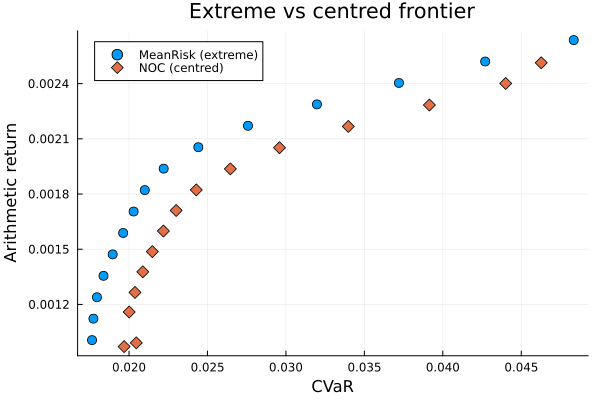

In [13]:
xs_M = [expected_risk(rcvar, w, pr.X) for w in resM.w]
ys_M = [expected_return(ArithmeticReturn(), w, pr) for w in resM.w]
xs_N = [expected_risk(rcvar, w, pr.X) for w in resN.w]
ys_N = [expected_return(ArithmeticReturn(), w, pr) for w in resN.w]

plot(xs_M, ys_M; seriestype = :scatter, marker = (:circle, 5), label = "MeanRisk (extreme)",
     xlabel = "CVaR", ylabel = "Arithmetic return", title = "Extreme vs centred frontier")
plot!(xs_N, ys_N; seriestype = :scatter, marker = (:diamond, 6), label = "NOC (centred)")

The composition along each frontier makes the same story visual: the `MeanRisk` frontier collapses
onto a handful of names as it climbs, while the NOC frontier keeps more assets in play for longer.

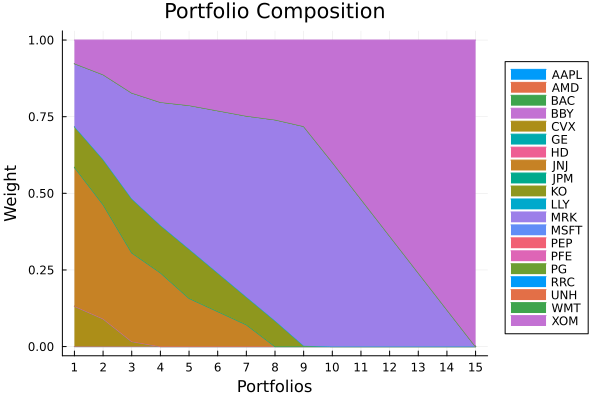

In [14]:
plot_stacked_area_composition(resM.w, rd.nx)

The same sweep under NOC — visibly more names carried up the frontier.

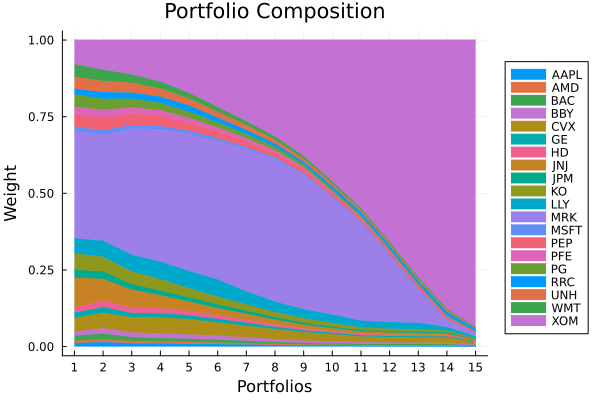

In [15]:
plot_stacked_area_composition(resN.w, rd.nx)

## 4. Visualising the frontier

The efficient frontier is a special case of a Pareto front, and `plot_measures` draws it on
any pair of risk/return axes. There are optional keyword parameters for the risk measure on the
X-axis, Y-axis, Z-axis, and colourbar. Here we put CVaR on the X-axis, the arithmetic return on the
Y-axis, and colour by the risk-return ratio.

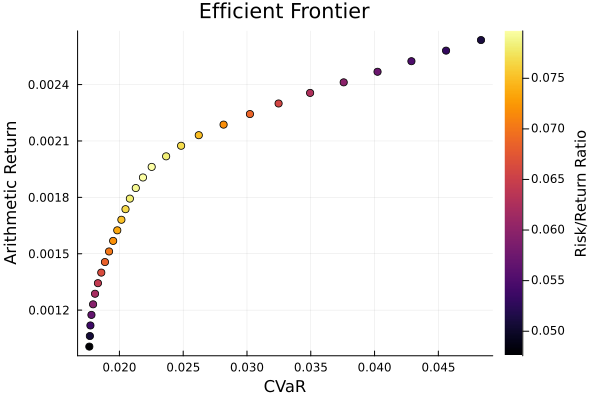

In [16]:
plot_measures(resA.w, resA.pr; x = r, y = ExpectedReturn(; rt = resA.ret),
              c = ExpectedReturnRiskRatio(; rt = resA.ret, rk = r, rf = rf),
              title = "Efficient Frontier", xlabel = "CVaR", ylabel = "Arithmetic Return",
              colorbar_title = "\nRisk/Return Ratio", right_margin = 6Plots.mm)

Because `plot_measures` works on *any* pair of measures, the same call plots arbitrary Pareto
fronts — we can even use the ratio of two risk measures as the colourbar.

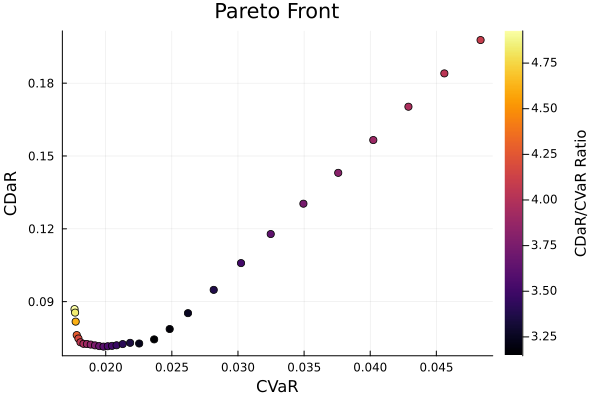

In [17]:
plot_measures(resA.w, resA.pr; x = r, y = ConditionalDrawdownatRisk(),
              c = RiskRatio(; r1 = ConditionalDrawdownatRisk(), r2 = r),
              title = "Pareto Front", xlabel = "CVaR", ylabel = "CDaR",
              colorbar_title = "\nCDaR/CVaR Ratio", right_margin = 6Plots.mm)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*